In [1]:
import numpy as np
from galpy.orbit import Orbit
from galpy.potential import KeplerPotential
import astropy.constants as acon
import astropy.units as u
import matplotlib.pyplot as plt

In [2]:
from scipy.spatial.transform import Rotation
from numpy.linalg import norm
from scipy.integrate import quad

In [3]:
num = 10000
t = 0
rs = 149600000

v_sun = np.array([12.9, 245.6, 7.78])
v_earth = np.array([0, 0, 0])
v_str = np.array([10, 0, 0])
v_c = v_str #- v_sun

normal = np.array([-v_c[1], v_c[0], 0])
rot = Rotation.from_rotvec(t * normal / norm(normal))
r = rot.apply(v_c)
r = r / norm(r) * rs



In [4]:
num = 50
points = []

dist = 1

z = np.linspace(-dist, dist, num) * rs * u.km
y = np.linspace(-dist, dist, num) * rs * u.km
x = 10 * rs * u.km

rho = np.sqrt(x*x + y*y)
phi = np.arctan(y/x)

for i in range(num):
    for j in range(num):
        sp = [x.value, y[j].value, z[i].value]
        esc = np.sqrt(acon.GM_sun * 2/ np.linalg.norm(np.array(sp)) / u.km) 
        esc = np.sqrt((acon.GM_sun * 2/ rs * (1 / 10)) / u.km + (20 * u.km / u.s)**2) 
        points.append([rho[j], -esc.to(u.km / u.s), 0 * u.km / u.s, z[i] , 0 * u.km / u.s, phi[j]])



In [5]:
# 1. Initialize the orbit [R, vR, vT, z, vz, phi]
o = Orbit(points)

# 2. Define a time array for integration



tf = np.sqrt(2 * (np.linalg.norm(sp) * u.km) ** 3 / 3 / acon.GM_sun).to(u.s).value
ts = np.linspace(0*tf, 1 * tf, 20000) * u.s


pot = KeplerPotential(acon.GM_sun)

# 3. Solve the equations of motion
o.integrate(ts, pot)

rs_kpc = (rs * u.km).to(u.kpc).value
# 4. Plot the resulting trajectory
#plt.xlim(-1 * rs_kpc, 5 * rs_kpc)
#plt.ylim(-2, 2)

(-9.69641163401754e-09, 9.69641163401754e-09)

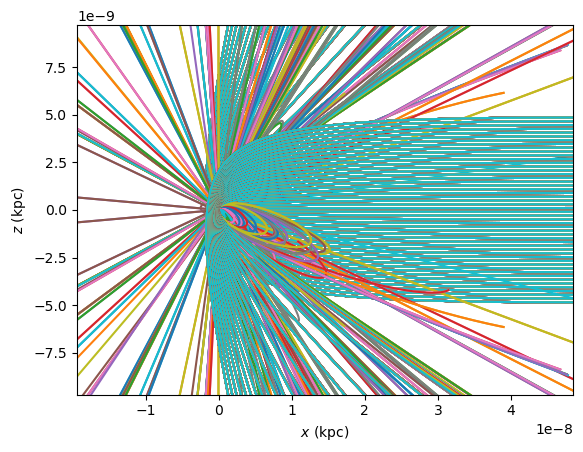

In [6]:
o.plot(d1 = 'x', d2='z')
plt.xlim(-4 * rs_kpc, 10 * rs_kpc)
plt.ylim(-2 * rs_kpc, 2 * rs_kpc)

In [7]:
orbit = o.getOrbit()


In [8]:
z = orbit[:, :, 3]
x = orbit[:, :, 0] * np.cos(orbit[:, :, -1])
y = orbit[:, :, 0] * np.sin(orbit[:, :, -1])
mask_ri = x**2 + z**2
mask_ri = np.sqrt(mask_ri)

mask1 = np.arctan(z / x)
#mask1[(x < 0) * (z > 0)] = np.pi - np.abs(mask1[(x < 0) * (z > 0)])
#mask1[(x < 0) * (z < 0)] = -np.pi + np.abs(mask1[(x < 0) * (z < 0)])

def denPoints(ri, ro, t1, t2, y1, y2):
        
    if t2 > t1:
        dummy = t1
        t1 = t2
        t2 = dummy
        
    
    if t2 < t1 - np.pi / 2:
        theta = t1 - t2
        theta = 2*np.pi - theta
    else:
        theta = t1 - t2
    
    ro = ((ro*rs * u.km).to(u.kpc) / 8).value
    ri = ((ri*rs * u.km).to(u.kpc) / 8).value
    
    area = theta * 2 /3 * (ro ** 2 - ri ** 2)
    
    mask_r = (mask_ri < ro) * (mask_ri > ri) * (y < y2) * (y > y1)
    
    #assuming t1 > t2
    if t2 < t1 - np.pi / 2:
        if t2 < 0 and t1 > 0:
            print('o', t2, t1)
            print((((mask1 <= t2) + (mask1 >= t1)) * mask_r).sum())
            return (((mask1 <= t2) + (mask1 >= t1)) * mask_r).sum() / area
        else: 
            print('oj')
            return ((mask1 <= t2) * (mask1 >= t1) * mask_r).sum() / area
    else:
        return ((mask1 <= t1) * (mask1 >= t2) * mask_r).sum() / area

In [9]:
mask1.min()

np.float64(-1.5707922343923446)

In [10]:
first = denPoints(9.8, 10, np.pi/20, -np.pi/20, -5, 5)
second = denPoints(0.9, 1.1, np.pi/2 - np.pi/10, -np.pi/2 + np.pi/10, -0.05, 0.05)
first

o -1.2566370614359172 1.2566370614359172
84568


np.float64(1.554929189760461e+24)

In [11]:
(rs * u.km).to(u.kpc) / 8

<Quantity 6.06025727e-10 kpc>

-1.544616388014982
1.5446163880149815
o -1.5184364492350668 1.5707963267948963
38772


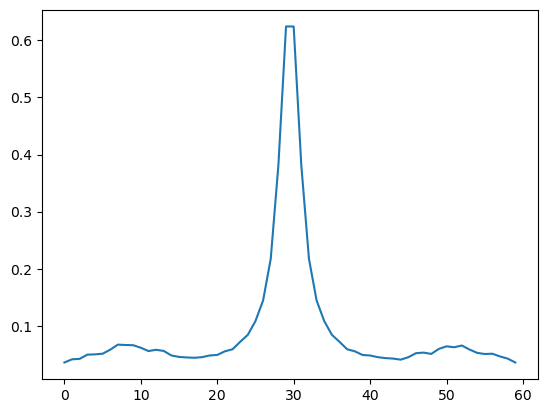

In [12]:
num = 30

def norm(t):
    if t > np.pi / 2:
        return t - np.pi
    if t <= -np.pi:
        return t + np.pi
    
    return t

first = denPoints(9.8, 10, np.pi/60, -np.pi/60, -5, 5)

y1 = ((0.005 * rs * u.km).to(u.kpc) / 8).value

sec = []
for i in range(0, num*2):
    if i == num:
        print(norm(np.pi/num / 4 + i * np.pi / 2/ num))
        print(norm(-np.pi/num / 4 + i * np.pi / 2/ num))
    second = denPoints(0.5, 1.5, 
                       norm((i+1) * np.pi / 2/ num), 
                       norm(i * np.pi / 2/ num), -y1, y1)
    sec.append(second/first)
    
plt.clf()
sec[num] = sec[num-1]
plt.plot(sec) 



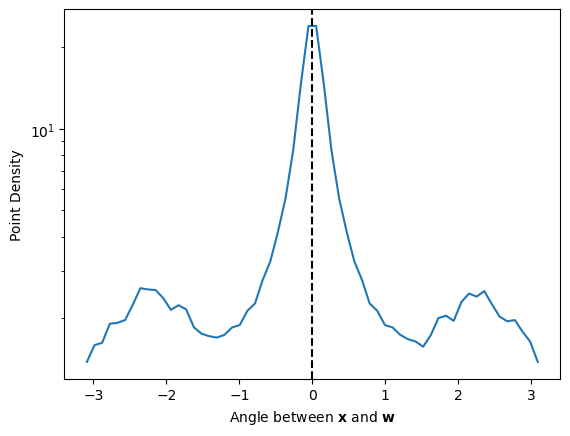

In [13]:
plt.clf()
t = np.arange(+np.pi/2/num, 2 * np.pi +np.pi/2/num , np.pi/num) - np.pi
sec = np.array(sec)
sec = sec / sec[0] * 1.3801765592846669 # normalise to whatever the jacobian says the density at the end should be
plt.semilogy(t, np.array(sec))

plt.ylabel("Point Density")
plt.xlabel("Angle between $\\mathbf{x}$ and $\\mathbf{w}$")
plt.axvline(0, ls="--", c= "black")

In [15]:
# From analyical solution, the value at ang ~ 0.05235987755983018 should be 20.63183794396858
sec[num], t[num]

(np.float64(23.97500248950962), np.float64(0.05235987755983018))